In [1]:
%load_ext autoreload
%autoreload 2

import os,sys
import util as yu
from util import *
import util_charge as yuc

yu.setpath('check_fits_tfmax')

enss=['b','c','d','e']

In [5]:
symmetrizeQ=True
extraLabel='' if symmetrizeQ else '_0sym'

[ens2pars_jk_meff1st,ens2pars_jk_meff2st,ens2pars_jk_meff3st]=yu.load_pkl_reg('ens2pars_jk_meffnst_selected',pathlabel='analysis_c2pt')

ens2data={}
for ens in enss:
    path=f'/p/project1/ngff/li47/code/projectData/07_Nsgm/charges/{yu.ens2full[ens]}.h5'
    [c2pt_disc,tfs_conn,tfs_disc,tf2c2pt_conn,key2tf2c3pt,key2tf2ratio]=yuc.load(path,symmetrizeQ=symmetrizeQ)
    if ens in ['b','c','d']:
        tfs_conn=tfs_conn[:-1]
    
    for key in key2tf2c3pt:
        key2tf2c3pt[key]={tf:key2tf2c3pt[key][tf] for tf in tfs_conn}
        key2tf2ratio[key]={tf:key2tf2ratio[key][tf] for tf in tfs_conn}
    
    ens2data[ens]=[c2pt_disc,tfs_conn,tfs_disc,tf2c2pt_conn,key2tf2c3pt,key2tf2ratio]

In [18]:
# for g in ['gS+;disc']:
#     for ens in enss:
#         pars_jk_meff2st=ens2pars_jk_meff2st[ens]
#         [c2pt_disc,tfs_conn,tfs_disc,tf2c2pt_conn,key2tf2c3pt,key2tf2ratio]=ens2data[ens]
#         tf2ratio=key2tf2ratio[g]
        
#         xunit=yu.ens2a[ens]
#         fig,axs=yu.makePlot_3pt_rainbow(tf2ratio,tfmin=8,tfmax=1.5/xunit,xunit=xunit,dt=2)
#         axs[0,0].set_ylim([-4,4])
#         yu.finalizePlot()

[verbose1] tfmin=8;
[verbose1] tfmin=10;
[verbose1] tfmin=12;
[verbose1] tfmin=14;
[verbose1] tfmin=8;
[verbose1] tfmin=10;
[verbose1] tfmin=12;
[verbose1] tfmin=14;
[verbose1] tfmin=8;
[verbose1] tfmin=10;
[verbose1] tfmin=12;
[verbose1] tfmin=14;
[verbose1] tfmin=8;
[verbose1] tfmin=10;
[verbose1] tfmin=12;
[verbose1] tfmin=14;
[verbose1] tfmin=8;
[verbose1] tfmin=10;
[verbose1] tfmin=12;
[verbose1] tfmin=14;
[verbose1] tfmin=8;
[verbose1] tfmin=10;
[verbose1] tfmin=12;
[verbose1] tfmin=14;
341(29)
[verbose1] tfmin=6;
[verbose1] tfmin=8;
[verbose1] tfmin=10;
[verbose1] tfmin=12;
[verbose1] tfmin=14;
[verbose1] tfmin=16;
[verbose1] tfmin=6;
[verbose1] tfmin=8;
[verbose1] tfmin=10;
[verbose1] tfmin=12;
[verbose1] tfmin=14;
[verbose1] tfmin=16;
[verbose1] tfmin=6;
[verbose1] tfmin=8;
[verbose1] tfmin=10;
[verbose1] tfmin=12;
[verbose1] tfmin=14;
[verbose1] tfmin=16;
[verbose1] tfmin=6;
[verbose1] tfmin=8;
[verbose1] tfmin=10;
[verbose1] tfmin=12;
[verbose1] tfmin=14;
[verbose1] tfmin=16

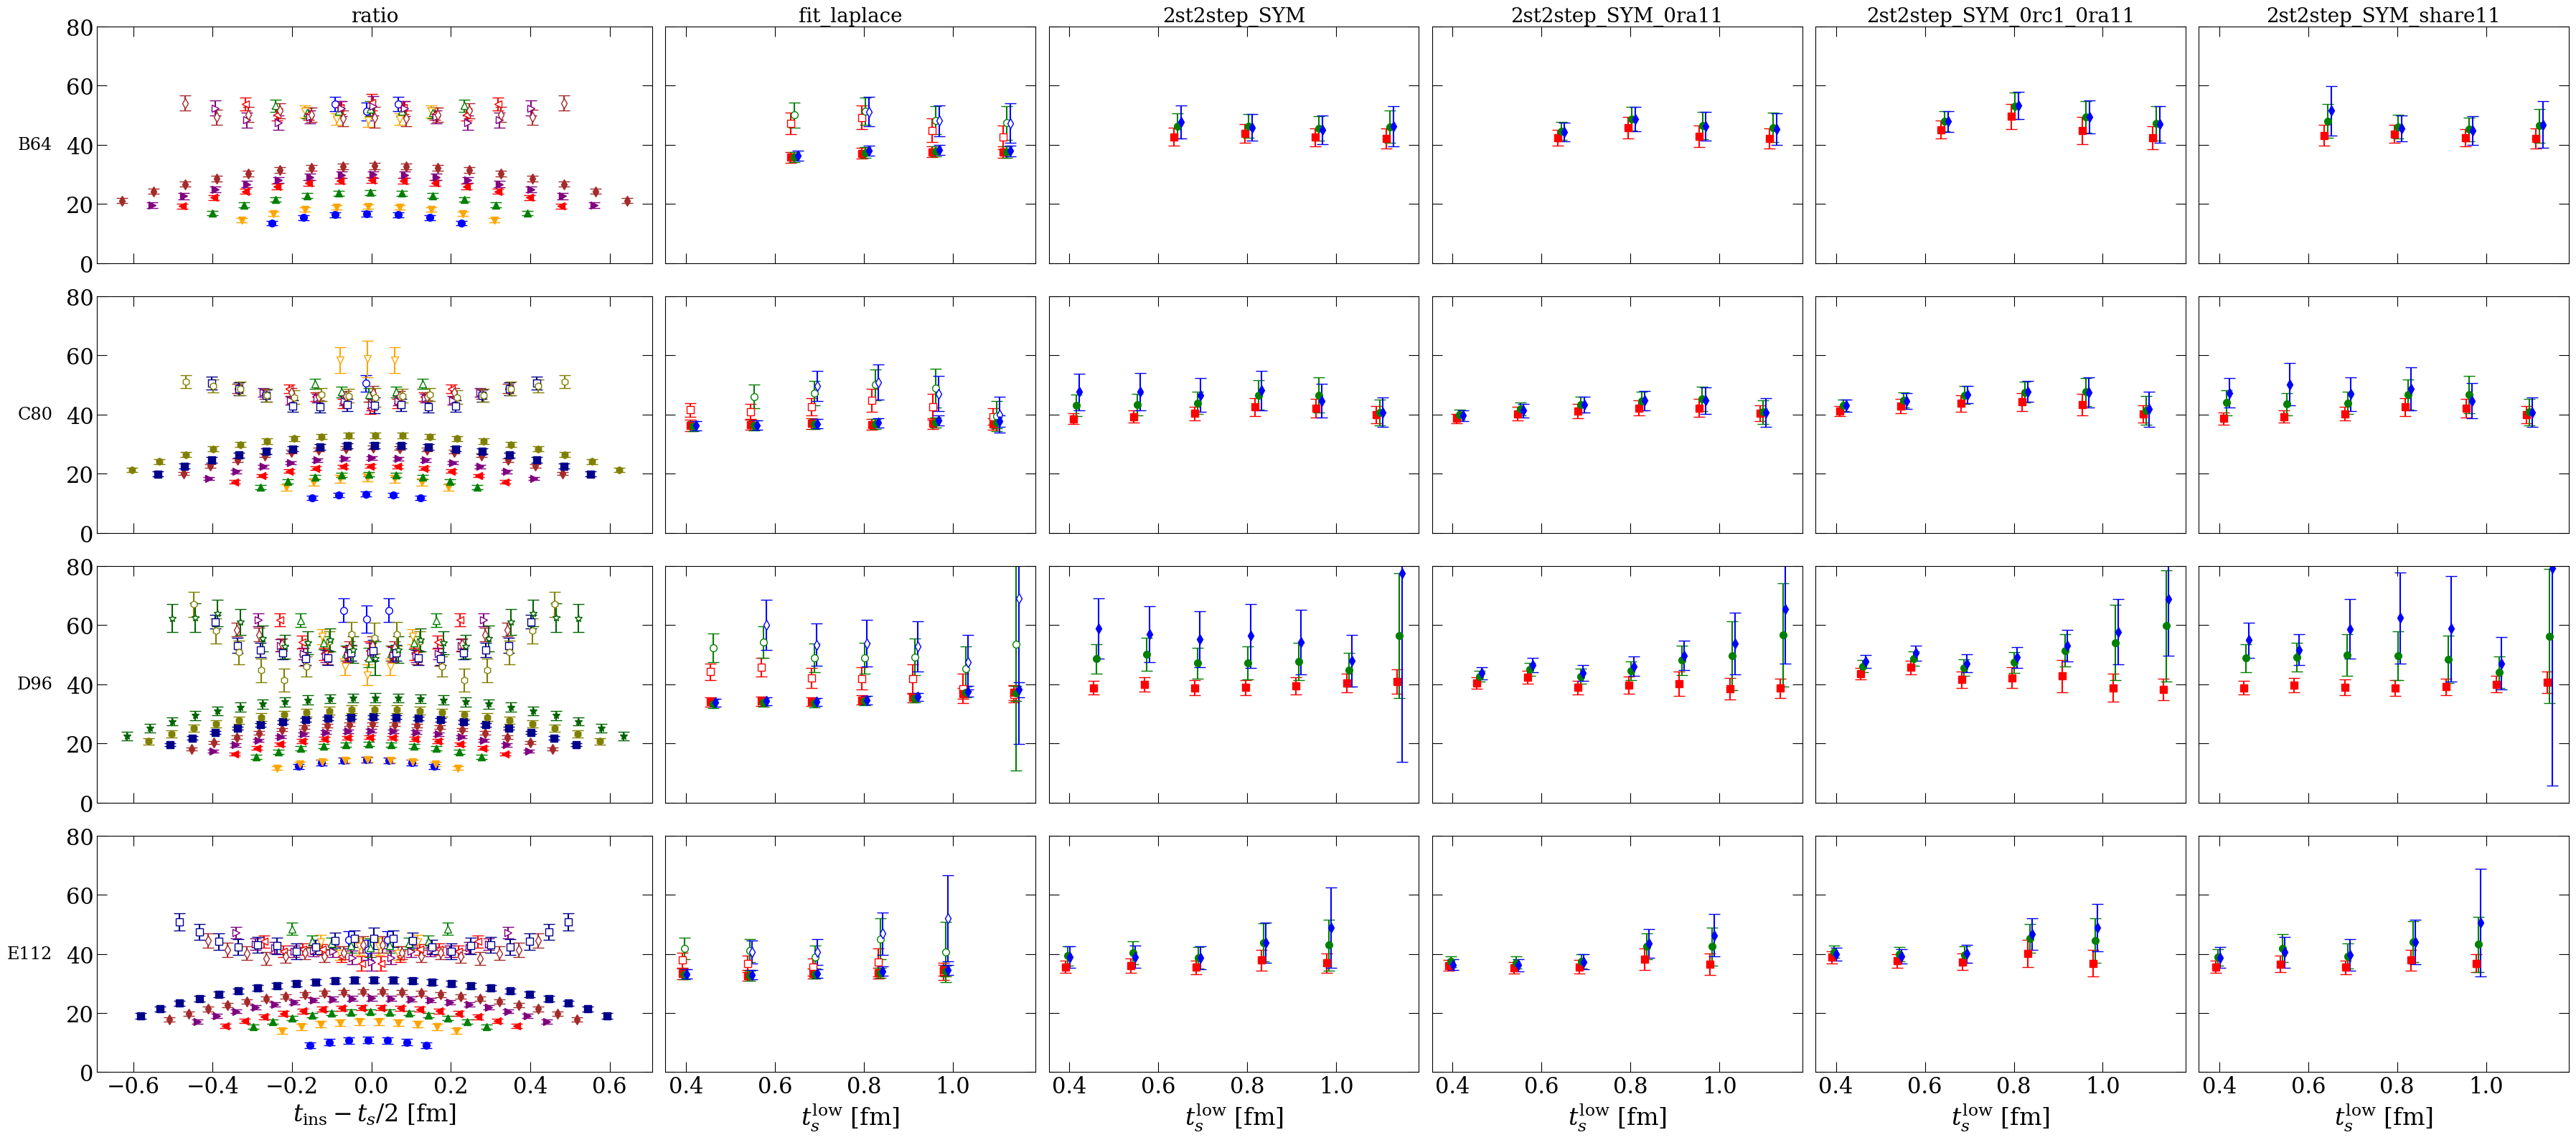

In [9]:
for g in ['gS+']:
    ens2dics={}
    for ens in enss:
        pars_jk_meff2st=ens2pars_jk_meff2st[ens]
        [c2pt_disc,tfs_conn,tfs_disc,tf2c2pt_conn,key2tf2c3pt,key2tf2ratio]=ens2data[ens]
        tf2ratio=key2tf2ratio[g]
        
        tfmins_2st=tfs_conn[:-2]
        # tcmins_2st=np.arange(1,int(0.5/yu.ens2a[ens]),int(0.2/yu.ens2a[ens]))
        tcmins_2st=[1,2,3]
        
        label2fits={}; label2fits_ds2={}; label2fits_unc={}
        for label in ['2st2step_SYM','2st2step_SYMshare','2st2step_SYM_0ra11','2st2step_SYM_0rc1_0ra11','2st2step_SYM_share11']:
            # print(ens,label)
            # label2fits[label]=yu.doFits_3pt(label,tf2ratio,tfmins_2st,tcmins_2st,pars_jk_meff2st=pars_jk_meff2st,symmetrizeQ=symmetrizeQ,label=f'{g}_{ens}_{label}',verbose=1)
            label2fits_ds2[label]=yu.doFits_3pt(label,tf2ratio,tfmins_2st,tcmins_2st,pars_jk_meff2st=pars_jk_meff2st,symmetrizeQ=symmetrizeQ,label=f'{g}_{ens}_{label}_ds2',verbose=1,downSampling=[1,2])
            
            
        # n=int(0.2/yu.ens2a[ens])
        n=2
        def dE2lbd(dE):
            lbd0=dE*n
            return np.sqrt(np.exp(-lbd0)+np.exp(lbd0)-2)
        
        def lbd2tf2ratio(dE):    
            lbd=dE2lbd(dE)
            
            tf2ratio={}
            for tf in tfs_conn:
                c3=key2tf2c3pt[g][tf]
                c3=-(np.roll(c3,-n,axis=-1)+np.roll(c3,n,axis=-1)-2*c3) + lbd**2*c3
                c2=(lbd**2)*c2pt_disc[:,tf]
                tf2ratio[tf]=c3/c2[:,None]
            return tf2ratio
        tfmins=tfmins_2st
        tcmins=[n+tcmin for tcmin in tcmins_2st]
        
        fits_laplace_ds2=yu.doFits_3pt_lbd(lbd2tf2ratio,tfmins,tcmins,symmetrizeQ=symmetrizeQ,label=f'{g}_{ens}_lbd_ds2',verbose=1,downSampling=[1,2],overwrite=False)
        fits_laplace_ds2=[[(tfmin,tcmin),np.array([pars_jk[:,0],np.abs(pars_jk[:,1])]).T,chi2_jk,Ndof] for (tfmin,tcmin),pars_jk,chi2_jk,Ndof in fits_laplace_ds2]

        fitlabel_chosen=(8,n+2)
        # fitlabel_chosen=fits_laplace_ds2[0][0]
        fit_MA_laplace=yu.doMA_3pt(fits_laplace_ds2,fitlabels=fitlabel_chosen)
        print(yu.jackme_un2str(fit_MA_laplace[0][:,1]*yu.ens2aInv[ens]))

        dE=np.mean(fit_MA_laplace[0][:,1])
        tf2ratio_laplace=lbd2tf2ratio(dE)
        # fits_const_2=yu.doFits_3pt('const',tf2ratio_laplace,tfmins,tcmins,symmetrizeQ=symmetrizeQ,label=f'const_2_laplace'+extraLabel)
        # fit_const_MA_2=yu.doMA_3pt(fits_const_2,fitlabels=fitlabel_chosen)

        xunit=yu.ens2a[ens]
        yunit=yu.ens2amul_iso[ens]*yu.ens2aInv[ens]
        
        dic={
            'base:[tf2ratio,fits_band,fits_const,fits_sum,fits_2st]':[tf2ratio,None,None,None,None],
            'WAMA:[fit_band_WA,fit_const_MA,fit_sum_MA,fit_2st_MA]':[None,None,None,None],
            'rainbow:[tfmin,tfmax,tcmin,dt]':[None,None,1,None],
            'xyunit':[xunit,yunit],
            'mfc:[global]':['None'],
        }
        dic_lbd={
            'base:[tf2ratio,fits_band,fits_const,fits_sum,fits_2st]':[tf2ratio_laplace,None,fits_laplace_ds2,None,None],
            'WAMA:[fit_band_WA,fit_const_MA,fit_sum_MA,fit_2st_MA]':[None,None,None,None],
            'rainbow:[tfmin,tfmax,tcmin,dt]':[None,None,n+1,None],
            'xyunit':[xunit,yunit],
            'mfc:[global]':['white'],
        }
        
        label2dic={}
        for label in label2fits_ds2.keys():
            label2dic[label]={
                'base:[tf2ratio,fits_band,fits_const,fits_sum,fits_2st]':[None,None,None,None,label2fits_ds2[label]],
                'WAMA:[fit_band_WA,fit_const_MA,fit_sum_MA,fit_2st_MA]':[None,None,None,None],
                'fit_2st:[tfmin_min,tfmin_max,tcmin_min,tcmin_max,dtf,dtc]':[None,None,None,5,None,None],
                'rainbow:[tfmin,tfmax,tcmin,dt]':[None,None,1,None],
                'xyunit':[xunit,yunit],
                'mfc:[global]':['None'],
            }
        
        ens2dics[ens]=[dic,dic_lbd,label2dic]
    
        
    colHeaders=['ratio','fit_laplace','2st2step_SYM','2st2step_SYM_0ra11','2st2step_SYM_0rc1_0ra11','2st2step_SYM_share11']
    fig,axs=yu.makePlot_3pt([ens2dics[ens][0] for ens in enss],shows=['rainbow'],colHeaders=colHeaders,fontsize_colHeaders=20, sharey=True)
    yu.addRowHeader(axs,[yu.ens2label[ens] for ens in enss])
    axs[0,0].set_ylim([0,80])
    fig,axs=yu.makePlot_3pt([ens2dics[ens][1] for ens in enss],shows=['rainbow']+[None]*(colHeaders.index('fit_laplace')-1)+['fit_const'],figAxs=(fig,axs),colHeaders=None)
    
    for i,label in enumerate(colHeaders):
        if label in label2dic.keys():
            fig,axs=yu.makePlot_3pt([ens2dics[ens][2][label] for ens in enss],shows=['rainbow']+[None]*(i-1)+['fit_2st'],figAxs=(fig,axs),colHeaders=None)
    fig,axs=yu.makePlot_3pt([ens2dics[ens][2]['2st2step_SYMshare'] for ens in enss],shows=['rainbow','fit_2st'],figAxs=(fig,axs),colHeaders=None)
            
    yu.finalizePlot()

In [4]:
def get(ens):
    g='gS+'
    fits=yu.getFits(f'{g}_{ens}_lbd_ds2')
    print(fits[0][0])
    
get('b')

(8, 3)
